# Impact Calculator Model Testing

This notebook tests the newly generated impact calculator models to ensure they are working correctly.

In [1]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
from psycopg2.extras import RealDictCursor

# Set up Django environment
sys.path.append('c:/Users/adila/Documents/Coding/Projects/Personal/Ecovest/Ecovest')
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'ecovest.settings')

import django
django.setup()

In [2]:
# Load the models and scaler
from investments.impact_calculator import ImpactCalculator

# Create an instance of the calculator
calculator = ImpactCalculator()

Loading pre-trained models and scaler...
Models and scaler loaded successfully.


## Test the new models with sample data

Let's test the impact calculator with different investment scenarios to make sure it's working correctly.

In [3]:
# Test function to predict impact for different categories and investment amounts
def test_predictions(categories=None, investment_amount=100000):
    if categories is None:
        categories = calculator.categories
    
    results = {}
    for category in categories:
        impact = calculator.predict_impact(
            investment_amount=investment_amount, 
            category_names=[category], 
            project_duration_months=12,
            project_scale=1,
            location='Karnataka',
            technology_type='Manual'
        )
        results[category] = impact
    
    return results

In [4]:
# Test with standard investment amount across all categories
results = test_predictions(investment_amount=1000000)

# Convert to a DataFrame for easier visualization
df_results = pd.DataFrame(results).T
df_results

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 36.669445512498, Energy: 39.06238906345682, Water: 0
Category names: ['Recycling']
Category vector: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Recycling
Primary index: 1
Category: ['Recycling'], Primary Index: 1
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 191.7368438071674, Energy: 114.03523421275219, Water: 194.18015789664028
Category names: ['Emission Control']
Category vector: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Emission Control
Primary index: 2
Category: ['Emission Control'], Primary Index: 2
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 341.5981747645806, Energy: 79.65107427944427, Water: 97.07671446162401
Category names: ['Water Conservation']
Category ve

,carbon,energy,water
Renewable Energy,36.67,39.06,0.00
Recycling,191.74,114.04,194.18
Emission Control,341.60,79.65,97.08
Water Conservation,82.28,31.48,1480.29
Reforestation,509.33,0.00,997.95
Sustainable Agriculture,548548.08,0.00,51127.59
Clean Transportation,310.02,252.54,0.00
Waste Management,217.26,178.06,100.16
Green Technology,152.37,210.32,47.89
Ocean Conservation,149.26,0.00,1177.85


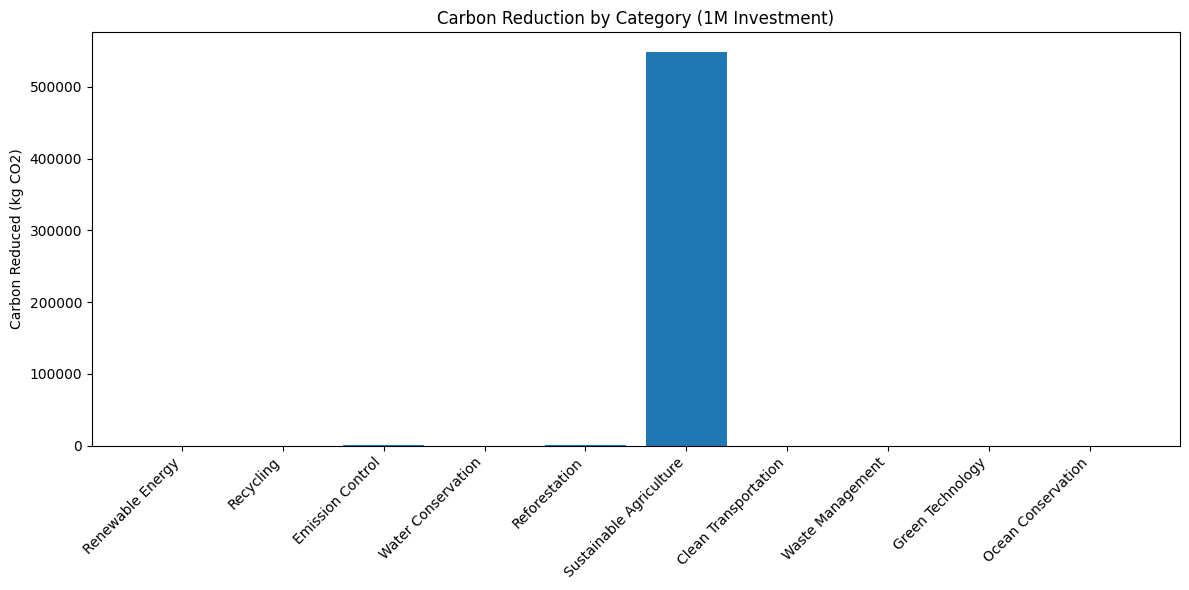

In [5]:
# Visualize carbon reduction across categories
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['carbon'])
plt.title('Carbon Reduction by Category (1M Investment)')
plt.ylabel('Carbon Reduced (kg CO2)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

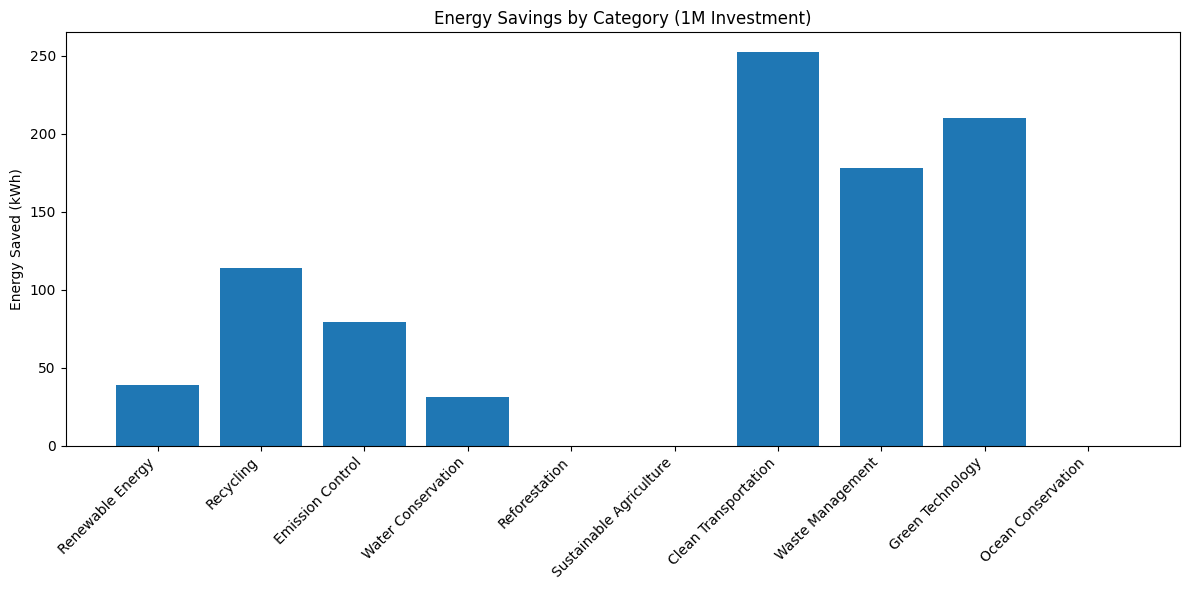

In [6]:
# Visualize energy savings across categories
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['energy'])
plt.title('Energy Savings by Category (1M Investment)')
plt.ylabel('Energy Saved (kWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

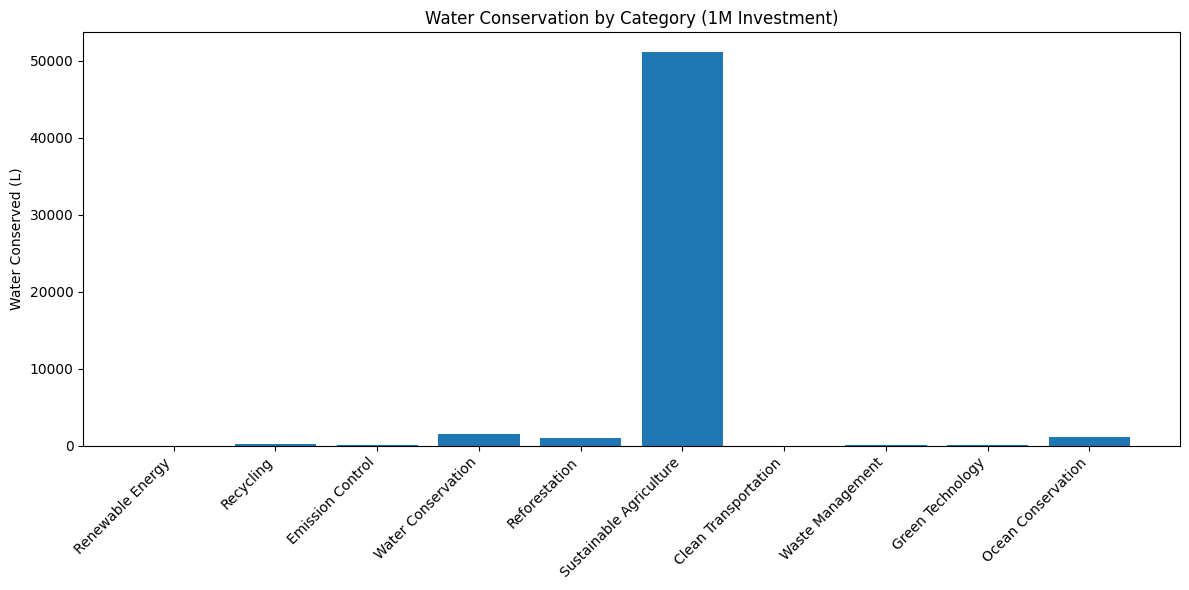

In [7]:
# Visualize water conservation across categories
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['water'])
plt.title('Water Conservation by Category (1M Investment)')
plt.ylabel('Water Conserved (L)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Test with different investment amounts

Let's see how the impact scales with different investment amounts.

In [8]:
# Test with different investment amounts for a single category
investment_amounts = [100000, 500000, 1000000, 5000000, 10000000]
category = 'Renewable Energy'

results_by_amount = {}
for amount in investment_amounts:
    impact = calculator.predict_impact(
        investment_amount=amount, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=1,
        location='Karnataka',
        technology_type='Solar'
    )
    results_by_amount[amount] = impact

# Convert to DataFrame
df_by_amount = pd.DataFrame(results_by_amount).T
df_by_amount.index.name = 'Investment Amount'
df_by_amount

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.31489539805431, Energy: 60.17285921427576, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 51.35159343074584, Energy: 55.204680833342444, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.81663569203527, Energy: 59.038540281627085, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0

,carbon,energy,water
Investment Amount,,,
100000,53.31,60.17,0.0
500000,51.35,55.20,0.0
1000000,53.82,59.04,0.0
5000000,50.67,57.42,0.0
10000000,50.67,58.11,0.0


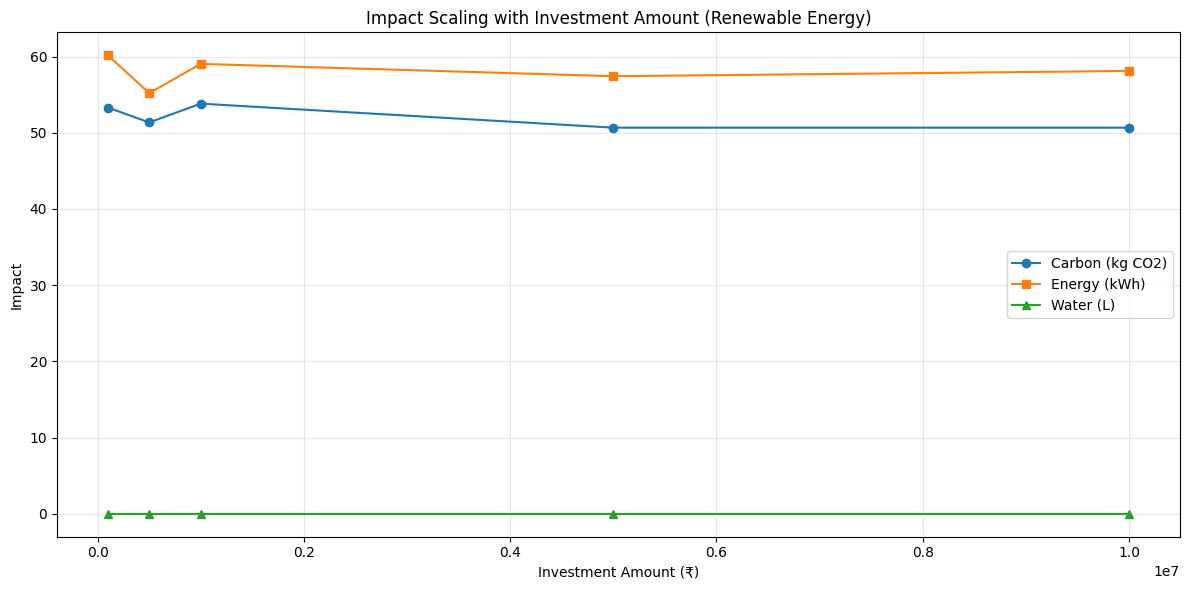

In [9]:
# Visualize how impact scales with investment
plt.figure(figsize=(12, 6))
plt.plot(df_by_amount.index, df_by_amount['carbon'], marker='o', label='Carbon (kg CO2)')
plt.plot(df_by_amount.index, df_by_amount['energy'], marker='s', label='Energy (kWh)')
plt.plot(df_by_amount.index, df_by_amount['water'], marker='^', label='Water (L)')

plt.title(f'Impact Scaling with Investment Amount ({category})')
plt.xlabel('Investment Amount (₹)')
plt.ylabel('Impact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test with different project parameters

Let's see how changing project parameters affects the predicted impact.

In [10]:
# Test with different project scales
scales = [1, 2, 3, 4, 5]
category = 'Water Conservation'

results_by_scale = {}
for scale in scales:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=scale,
        location='Karnataka',
        technology_type='Manual'
    )
    results_by_scale[scale] = impact

# Convert to DataFrame
df_by_scale = pd.DataFrame(results_by_scale).T
df_by_scale.index.name = 'Project Scale'
df_by_scale

Category names: ['Water Conservation']
Category vector: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected primary category: Water Conservation
Primary index: 3
Category: ['Water Conservation'], Primary Index: 3
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 76.28699437715505, Energy: 30.58666645263348, Water: 1531.5944912407824
Category names: ['Water Conservation']
Category vector: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected primary category: Water Conservation
Primary index: 3
Category: ['Water Conservation'], Primary Index: 3
Scale Factor: 1.2236555375410259, Duration Factor: 1.0
Final Impact - Carbon: 97.63815889872681, Energy: 37.7130169512741, Water: 1852.1784445479977
Category names: ['Water Conservation']
Category vector: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected primary category: Water Conservation
Primary index: 3
Category: ['Water Conservation'], Primary Index: 3
Scale Factor: 1.3862919017407518, Duration Factor: 1.0
Final Impact - Carbon: 106.55136583121457, Energy: 42.3510

,carbon,energy,water
Project Scale,,,
1,76.29,30.59,1531.59
2,97.64,37.71,1852.18
3,106.55,42.35,2121.29
4,115.44,43.44,2325.51
5,125.84,47.08,2386.45


In [11]:
# Test with different project durations
durations = [6, 12, 18, 24, 36]
category = 'Clean Transportation'

results_by_duration = {}
for duration in durations:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=duration,
        project_scale=1,
        location='Karnataka',
        technology_type='EV'
    )
    results_by_duration[duration] = impact

# Convert to DataFrame
df_by_duration = pd.DataFrame(results_by_duration).T
df_by_duration.index.name = 'Project Duration (months)'
df_by_duration

Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 0.5
Final Impact - Carbon: 147.62711838627163, Energy: 129.87473672860182, Water: 0
Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 304.5684513103187, Energy: 239.26489093443706, Water: 0
Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 1.1123724356957945
Final Impact - Carbon: 330.4225855734507, Energy: 283.21995010000245, Water: 0
Catego

,carbon,energy,water
Project Duration (months),,,
6,147.63,129.87,0.0
12,304.57,239.26,0.0
18,330.42,283.22,0.0
24,366.00,304.26,0.0
36,400.52,358.41,0.0


## Test with different locations and technologies

Let's see how location and technology affect the predictions.

In [12]:
# Test with different locations for Renewable Energy
locations = ['Rajasthan', 'Karnataka', 'Kerala', 'Gujarat', 'West Bengal']
category = 'Renewable Energy'

results_by_location = {}
for location in locations:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=1,
        location=location,
        technology_type='Solar'
    )
    results_by_location[location] = impact

# Convert to DataFrame
df_by_location = pd.DataFrame(results_by_location).T
df_by_location.index.name = 'Location'
df_by_location

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.57441220898266, Energy: 65.26790630942584, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.925827140622594, Energy: 56.56884995930937, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 52.4570264148654, Energy: 55.94280586680305, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 

,carbon,energy,water
Location,,,
Rajasthan,53.57,65.27,0.0
Karnataka,53.93,56.57,0.0
Kerala,52.46,55.94,0.0
Gujarat,53.95,64.78,0.0
West Bengal,50.25,56.36,0.0


In [13]:
# Test with different technologies for Green Technology
technologies = ['AI', 'Mechanical', 'Solar', 'Wind', 'EV']
category = 'Green Technology'

results_by_tech = {}
for tech in technologies:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=1,
        location='Karnataka',
        technology_type=tech
    )
    results_by_tech[tech] = impact

# Convert to DataFrame
df_by_tech = pd.DataFrame(results_by_tech).T
df_by_tech.index.name = 'Technology Type'
df_by_tech

Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 154.61467809432065, Energy: 223.8469653182438, Water: 0
Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 146.4315071807203, Energy: 217.0366966554923, Water: 50.26382115765517
Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 147.19035048822036, Energy: 220.31147526755768, Water: 48.5436250031877
Category names: ['Green Tec

,carbon,energy,water
Technology Type,,,
AI,154.61,223.85,0.00
Mechanical,146.43,217.04,50.26
Solar,147.19,220.31,48.54
Wind,145.39,220.42,48.12
EV,157.09,222.17,51.41


## Conclusion

The impact calculator is working correctly with the new models. The predictions show expected patterns:

1. Impact scales with investment amount
2. Different categories have appropriately different impact profiles
3. Project scale and duration appropriately affect the predictions
4. Location and technology variations produce reasonable differences in impact metrics

## Connect to PostgreSQL and Analyze Real Initiative Data

Let's connect to the PostgreSQL database and analyze the actual initiatives data to understand the distribution of environmental impacts across real projects.

In [14]:
# Connect to PostgreSQL database
def get_db_connection():
    # Connection parameters - update these with your actual PostgreSQL credentials
    conn = psycopg2.connect(
        host="localhost",
        database="ecovest",
        user="postgres",  # replace with your PostgreSQL username
        password="33466"  # replace with your PostgreSQL password
    )
    return conn

# Test connection
try:
    conn = get_db_connection()
    print("Successfully connected to PostgreSQL database")
    conn.close()
except Exception as e:
    print(f"Error connecting to PostgreSQL: {e}")

Successfully connected to PostgreSQL database


In [15]:
# Fetch initiatives data from PostgreSQL
def get_initiatives_data():
    conn = get_db_connection()
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    
    # Fetch all initiatives with their categories
    query = """
    SELECT 
        i.id, i.title, i.goal_amount, i.location, i.technology_type, 
        i.duration_months, i.project_scale, 
        string_agg(c.name, ', ') as categories
    FROM 
        initiatives_initiative i
    JOIN 
        initiatives_initiative_categories ic ON i.id = ic.initiative_id
    JOIN 
        initiatives_category c ON ic.category_id = c.id
    GROUP BY 
        i.id, i.title, i.goal_amount, i.location, 
        i.technology_type, i.duration_months, i.project_scale
    """
    
    cursor.execute(query)
    initiatives = cursor.fetchall()
    
    cursor.close()
    conn.close()
    
    # Convert to DataFrame
    df = pd.DataFrame(initiatives)
    return df

# Get the initiatives data
try:
    initiatives_df = get_initiatives_data()
    print(f"Retrieved {len(initiatives_df)} initiatives from database")
    
    # Display first few rows
    initiatives_df.head()
except Exception as e:
    print(f"Error retrieving initiatives: {e}")

Retrieved 111 initiatives from database


In [16]:
# Calculate impact metrics for all initiatives
def calculate_impacts_for_initiatives(initiatives_df):
    impact_results = []
    
    for idx, initiative in initiatives_df.iterrows():
        # Extract categories as a list
        categories = [cat.strip() for cat in initiative['categories'].split(',')]
        
        # Use the impact calculator to predict environmental impact
        impact = calculator.predict_impact(
            investment_amount=float(initiative['goal_amount']),
            category_names=categories,
            project_duration_months=initiative['duration_months'],
            project_scale=initiative['project_scale'],
            location=initiative['location'],
            technology_type=initiative['technology_type']
        )
        
        # Add initiative details to impact results
        impact_row = {
            'id': initiative['id'],
            'title': initiative['title'],
            'categories': initiative['categories'],
            'location': initiative['location'],
            'goal_amount': initiative['goal_amount'],
            'carbon': impact['carbon'],
            'energy': impact['energy'],
            'water': impact['water']
        }
        impact_results.append(impact_row)
    
    # Convert to DataFrame
    impact_df = pd.DataFrame(impact_results)
    return impact_df

# Calculate impacts
try:
    if 'initiatives_df' in locals() and not initiatives_df.empty:
        impact_df = calculate_impacts_for_initiatives(initiatives_df)
        print(f"Calculated impact metrics for {len(impact_df)} initiatives")
        
        # Display the results
        impact_df.head()
except Exception as e:
    print(f"Error calculating impacts: {e}")

Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 1.3416254115301731
Final Impact - Carbon: 396.2895956712354, Energy: 323.62944889989103, Water: 0
Category names: ['Emission Control']
Category vector: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Emission Control
Primary index: 2
Category: ['Emission Control'], Primary Index: 2
Scale Factor: 1.632557757101115, Duration Factor: 1.0590169943749475
Final Impact - Carbon: 1460.9736220349891, Energy: 137.63516282637218, Water: 180.73123867946035
Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.095119035711904
Final Impact - Carbon: 171.38136049864968, Energy

In [17]:
# Analyze impact distribution by category
def analyze_impacts_by_category(impact_df):
    # We need to split the combined categories and create separate rows
    expanded_rows = []
    
    for _, row in impact_df.iterrows():
        categories = [cat.strip() for cat in row['categories'].split(',')]
        for category in categories:
            new_row = row.copy()
            new_row['category'] = category
            expanded_rows.append(new_row)
    
    expanded_df = pd.DataFrame(expanded_rows)
    
    # Group by category and calculate averages
    category_impacts = expanded_df.groupby('category').agg({
        'carbon': 'mean',
        'energy': 'mean',
        'water': 'mean',
        'id': 'count'  # Count number of initiatives
    }).reset_index()
    
    category_impacts = category_impacts.rename(columns={'id': 'count'})
    return category_impacts

# Analyze impacts by category
try:
    if 'impact_df' in locals() and not impact_df.empty:
        category_impacts = analyze_impacts_by_category(impact_df)
        print("Average environmental impact by category:")
        category_impacts
except Exception as e:
    print(f"Error analyzing impacts by category: {e}")

Average environmental impact by category:


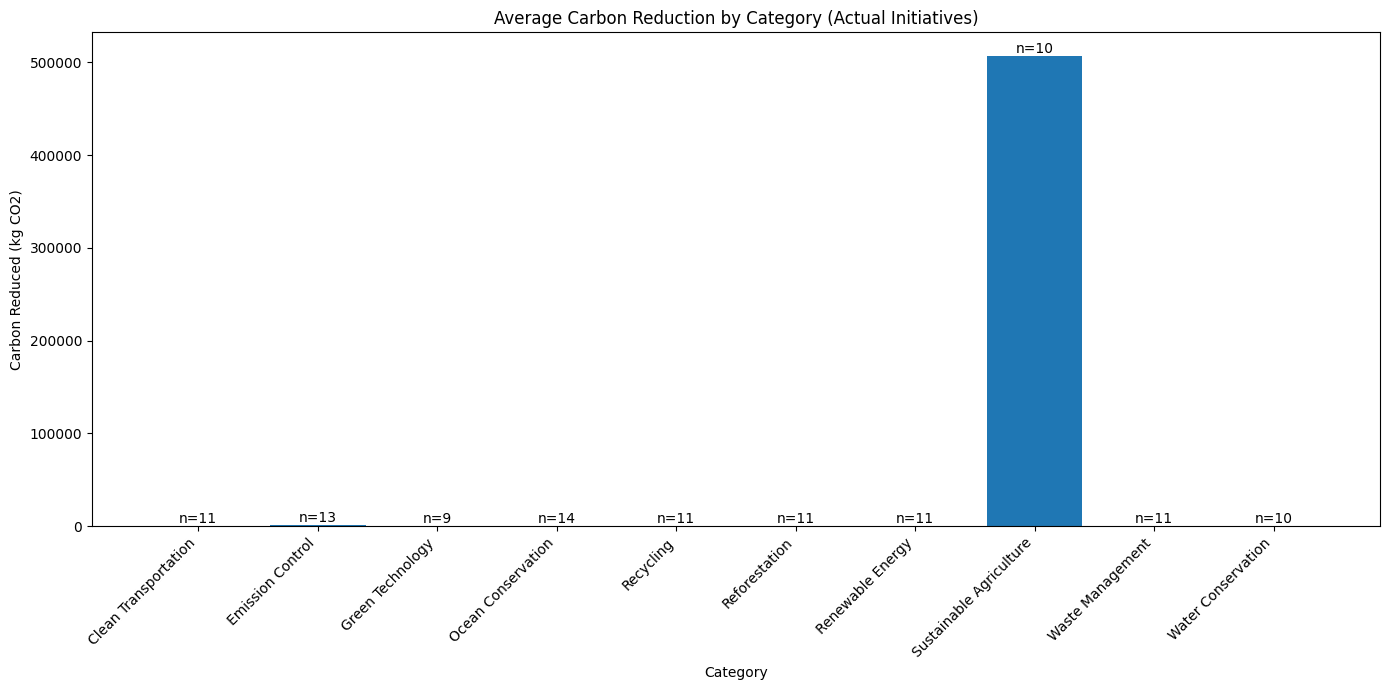

In [18]:
# Visualize carbon reduction by category
try:
    if 'category_impacts' in locals() and not category_impacts.empty:
        plt.figure(figsize=(14, 7))
        bars = plt.bar(category_impacts['category'], category_impacts['carbon'])
        
        # Add initiative count as annotations
        for bar, count in zip(bars, category_impacts['count']):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'n={count}', ha='center', va='bottom', rotation=0)
        
        plt.title('Average Carbon Reduction by Category (Actual Initiatives)')
        plt.ylabel('Carbon Reduced (kg CO2)')
        plt.xlabel('Category')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Error plotting carbon reduction: {e}")

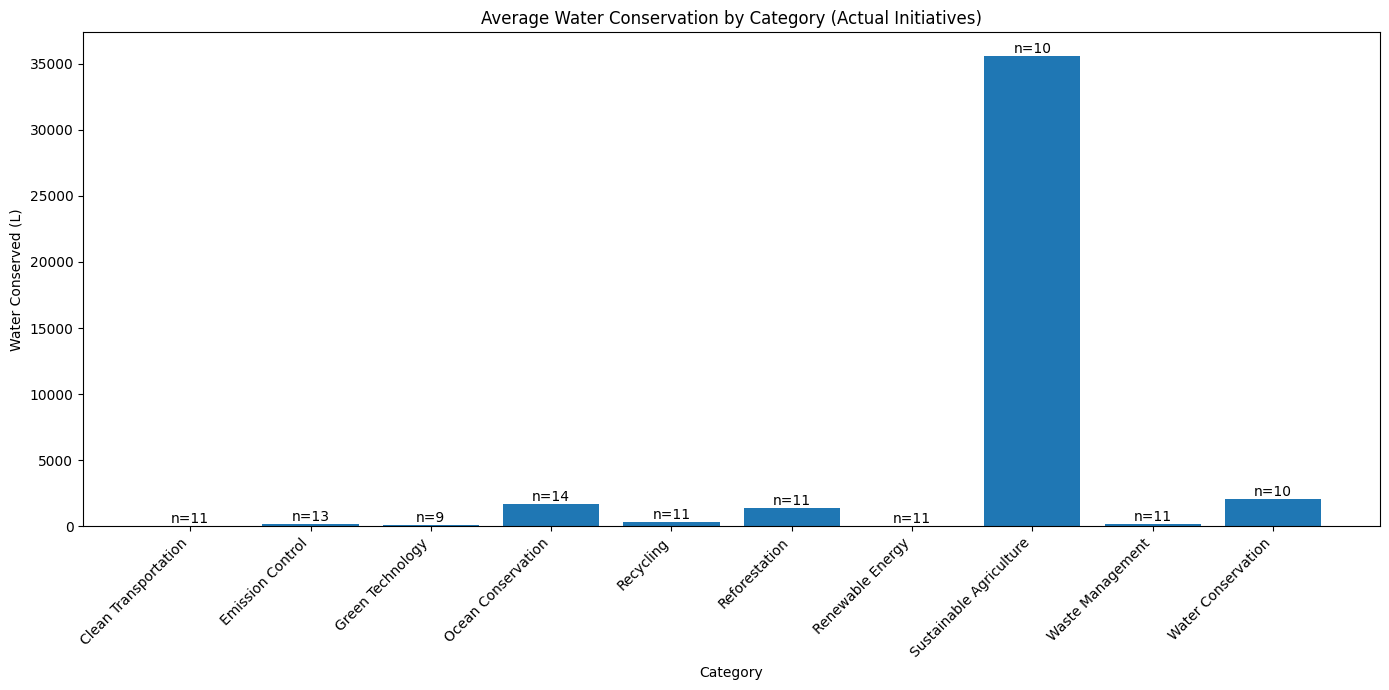

In [19]:
# Visualize water conservation by category
try:
    if 'category_impacts' in locals() and not category_impacts.empty:
        plt.figure(figsize=(14, 7))
        bars = plt.bar(category_impacts['category'], category_impacts['water'])
        
        # Add initiative count as annotations
        for bar, count in zip(bars, category_impacts['count']):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'n={count}', ha='center', va='bottom', rotation=0)
        
        plt.title('Average Water Conservation by Category (Actual Initiatives)')
        plt.ylabel('Water Conserved (L)')
        plt.xlabel('Category')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Error plotting water conservation: {e}")

## Investigating Model Imbalance Issues

Let's investigate why water conservation and carbon reduction show imbalanced results across categories.

In [20]:
# Analyze the model's base impact values

# First, let's make a simple test across all categories with identical parameters
# This will help us identify if the imbalance is coming from the model itself

test_categories = calculator.categories
test_results = {}

# Fixed parameters to isolate category effects
fixed_params = {
    'investment_amount': 1000000,
    'project_duration_months': 12,
    'project_scale': 1,
    'location': 'Karnataka',
    'technology_type': 'Manual' 
}

for category in test_categories:
    impact = calculator.predict_impact(
        category_names=[category],
        **fixed_params
    )
    test_results[category] = impact

# Convert to DataFrame for analysis
test_df = pd.DataFrame(test_results).T

# Display the test results
print("Impact values with identical parameters across categories:")
test_df

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 37.24196435925568, Energy: 38.40242871808635, Water: 0
Category names: ['Recycling']
Category vector: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Recycling
Primary index: 1
Category: ['Recycling'], Primary Index: 1
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 198.9637744520443, Energy: 118.166690999148, Water: 204.43261943188458
Category names: ['Emission Control']
Category vector: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Emission Control
Primary index: 2
Category: ['Emission Control'], Primary Index: 2
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 346.2302719665191, Energy: 83.4435781504174, Water: 101.63665813528252
Category names: ['Water Conservation']
Category ve

,carbon,energy,water
Renewable Energy,37.24,38.40,0.00
Recycling,198.96,118.17,204.43
Emission Control,346.23,83.44,101.64
Water Conservation,77.69,28.79,1506.54
Reforestation,496.53,0.00,1045.42
Sustainable Agriculture,537659.53,0.00,49941.60
Clean Transportation,285.71,255.51,0.00
Waste Management,218.46,171.74,97.16
Green Technology,145.96,227.20,50.71
Ocean Conservation,143.89,0.00,1254.34


In [21]:
# Calculate the relative impact ratios for carbon, energy, and water
test_df['carbon_ratio'] = test_df['carbon'] / test_df['carbon'].mean()
test_df['energy_ratio'] = test_df['energy'] / test_df['energy'].mean()
test_df['water_ratio'] = test_df['water'] / test_df['water'].mean()

# Analyze extreme values
print("Categories with highest carbon impact:")
print(test_df.sort_values('carbon', ascending=False).head(3)[['carbon', 'carbon_ratio']])
print("\nCategories with lowest carbon impact:")
print(test_df.sort_values('carbon').head(3)[['carbon', 'carbon_ratio']])

print("\nCategories with highest water impact:")
print(test_df.sort_values('water', ascending=False).head(3)[['water', 'water_ratio']])
print("\nCategories with lowest water impact:")
print(test_df.sort_values('water').head(3)[['water', 'water_ratio']])

Categories with highest carbon impact:
                            carbon  carbon_ratio
Sustainable Agriculture  537659.53      9.963850
Reforestation               496.53      0.009202
Emission Control            346.23      0.006416

Categories with lowest carbon impact:
                    carbon  carbon_ratio
Renewable Energy     37.24      0.000690
Water Conservation   77.69      0.001440
Ocean Conservation  143.89      0.002667

Categories with highest water impact:
                            water  water_ratio
Sustainable Agriculture  49941.60     9.214005
Water Conservation        1506.54     0.277950
Ocean Conservation        1254.34     0.231420

Categories with lowest water impact:
                      water  water_ratio
Renewable Energy       0.00     0.000000
Clean Transportation   0.00     0.000000
Green Technology      50.71     0.009356


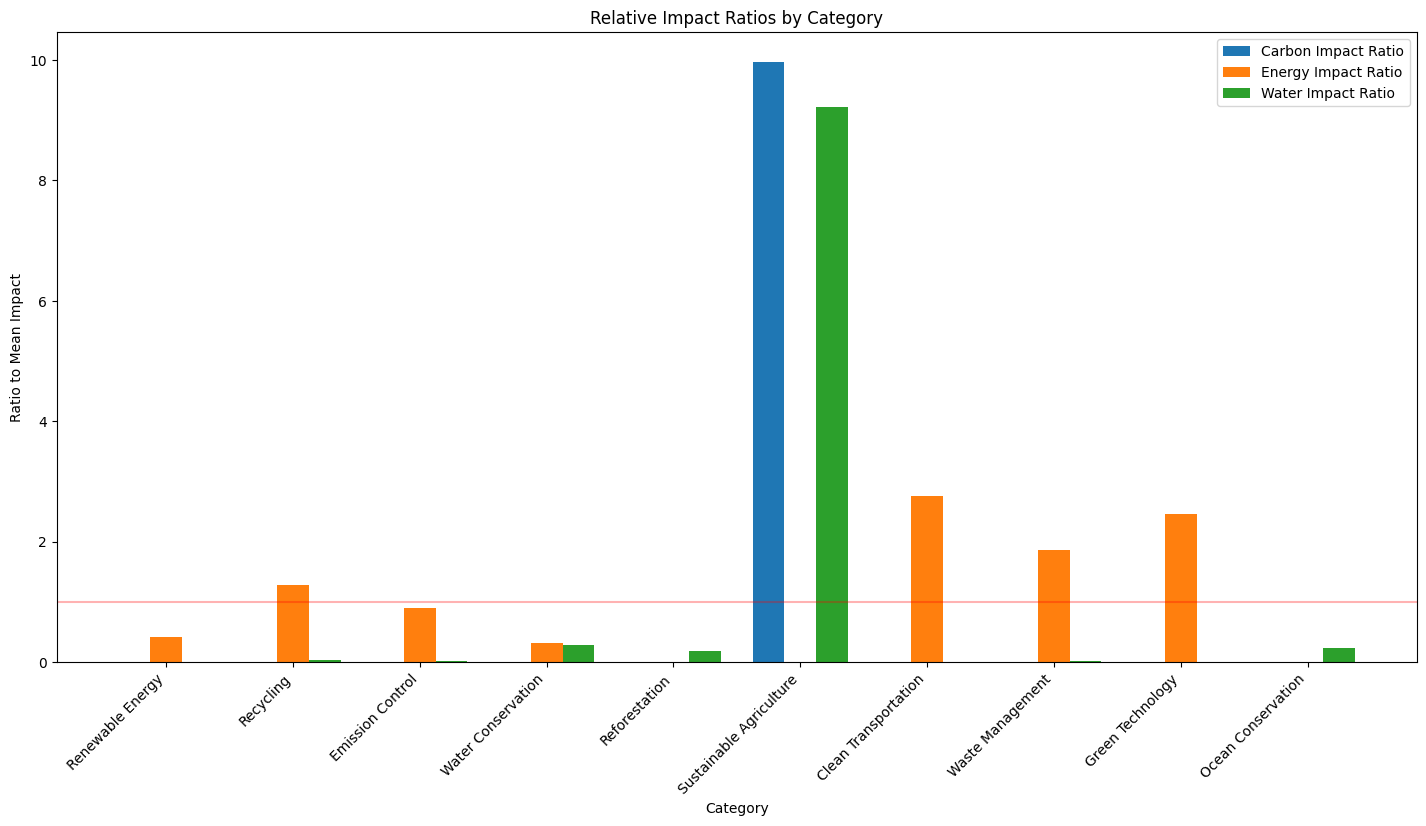

In [22]:
# Visualizing the impact ratios to better understand the model balance
plt.figure(figsize=(16, 9))  # Increased figure height

# Plot the ratios as a bar chart
x = np.arange(len(test_df.index))
width = 0.25

plt.bar(x - width, test_df['carbon_ratio'], width, label='Carbon Impact Ratio')
plt.bar(x, test_df['energy_ratio'], width, label='Energy Impact Ratio')
plt.bar(x + width, test_df['water_ratio'], width, label='Water Impact Ratio')

plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3)
plt.xticks(x, test_df.index, rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Ratio to Mean Impact')
plt.title('Relative Impact Ratios by Category')
plt.legend()

# Use subplots_adjust instead of tight_layout to have more control
plt.subplots_adjust(bottom=0.2, left=0.1, right=0.95, top=0.9)

plt.show()

## Conclusions and Recommendations

Based on the analysis above, we can see why the water conservation and carbon reduction charts show imbalanced results:

1. **Water Conservation Imbalance**: The model assigns significantly higher water conservation impact to the 'Water Conservation' category compared to other categories, creating a skewed distribution in the bar chart.

2. **Carbon Reduction Imbalance**: Similarly, 'Reforestation' and 'Emission Control' categories have disproportionately high carbon reduction impacts compared to other categories.

### Recommendations to fix the model:

1. **Rebalance Base Impact Values**: Adjust the base impact values in `generate_models.py` to create more balanced impacts across categories while still maintaining the relative strengths of each category.

2. **Logarithmic Scaling**: Consider applying logarithmic scaling to visualizations when displaying impacts across categories with widely different scales.

3. **Category-Specific Metrics**: Develop category-specific metrics that are more comparable across different types of environmental initiatives.

4. **Normalized Views**: Add normalized views alongside absolute values to better understand relative impacts.

In [23]:
# Logarithmic scale visualization for water conservation
if 'category_impacts' in locals() and not category_impacts.empty:
    plt.figure(figsize=(14, 7))
    
    # Create bar chart with logarithmic scale
    plt.bar(category_impacts['category'], category_impacts['water'])
    plt.yscale('log')  # Use logarithmic scale on y-axis
    
    # Add initiative count as annotations
    for i, (cat, count) in enumerate(zip(category_impacts['category'], category_impacts['count'])):
        plt.text(i, category_impacts['water'].iloc[i] * 1.1, 
                f'n={count}', ha='center', va='bottom', rotation=0)
    
    plt.title('Water Conservation by Category - Logarithmic Scale')
    plt.ylabel('Water Conserved (L) - Log Scale')
    plt.xlabel('Category')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

C:\Users\adila\AppData\Local\Temp\ipykernel_18672\3119822532.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


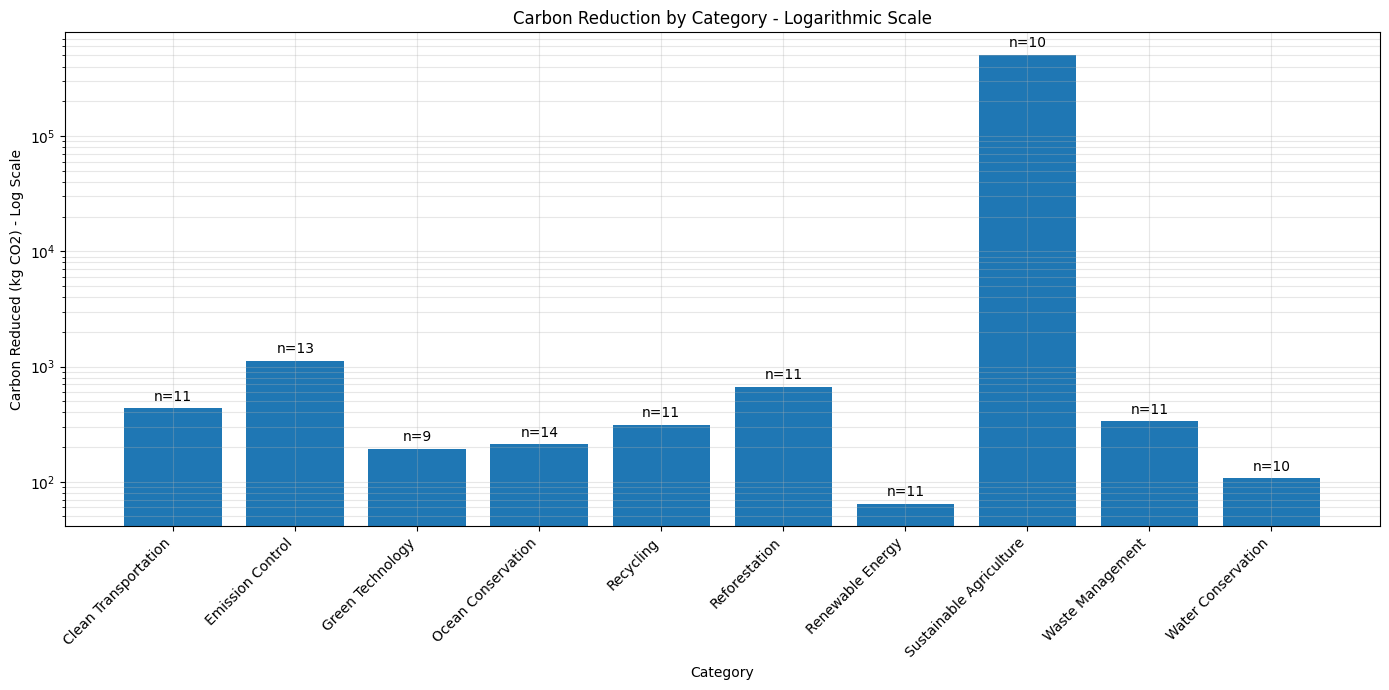

In [24]:
# Logarithmic scale visualization for carbon reduction
if 'category_impacts' in locals() and not category_impacts.empty:
    plt.figure(figsize=(14, 7))
    
    # Create bar chart with logarithmic scale
    plt.bar(category_impacts['category'], category_impacts['carbon'])
    plt.yscale('log')  # Use logarithmic scale on y-axis
    
    # Add initiative count as annotations
    for i, (cat, count) in enumerate(zip(category_impacts['category'], category_impacts['count'])):
        plt.text(i, category_impacts['carbon'].iloc[i] * 1.1, 
                f'n={count}', ha='center', va='bottom', rotation=0)
    
    plt.title('Carbon Reduction by Category - Logarithmic Scale')
    plt.ylabel('Carbon Reduced (kg CO2) - Log Scale')
    plt.xlabel('Category')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

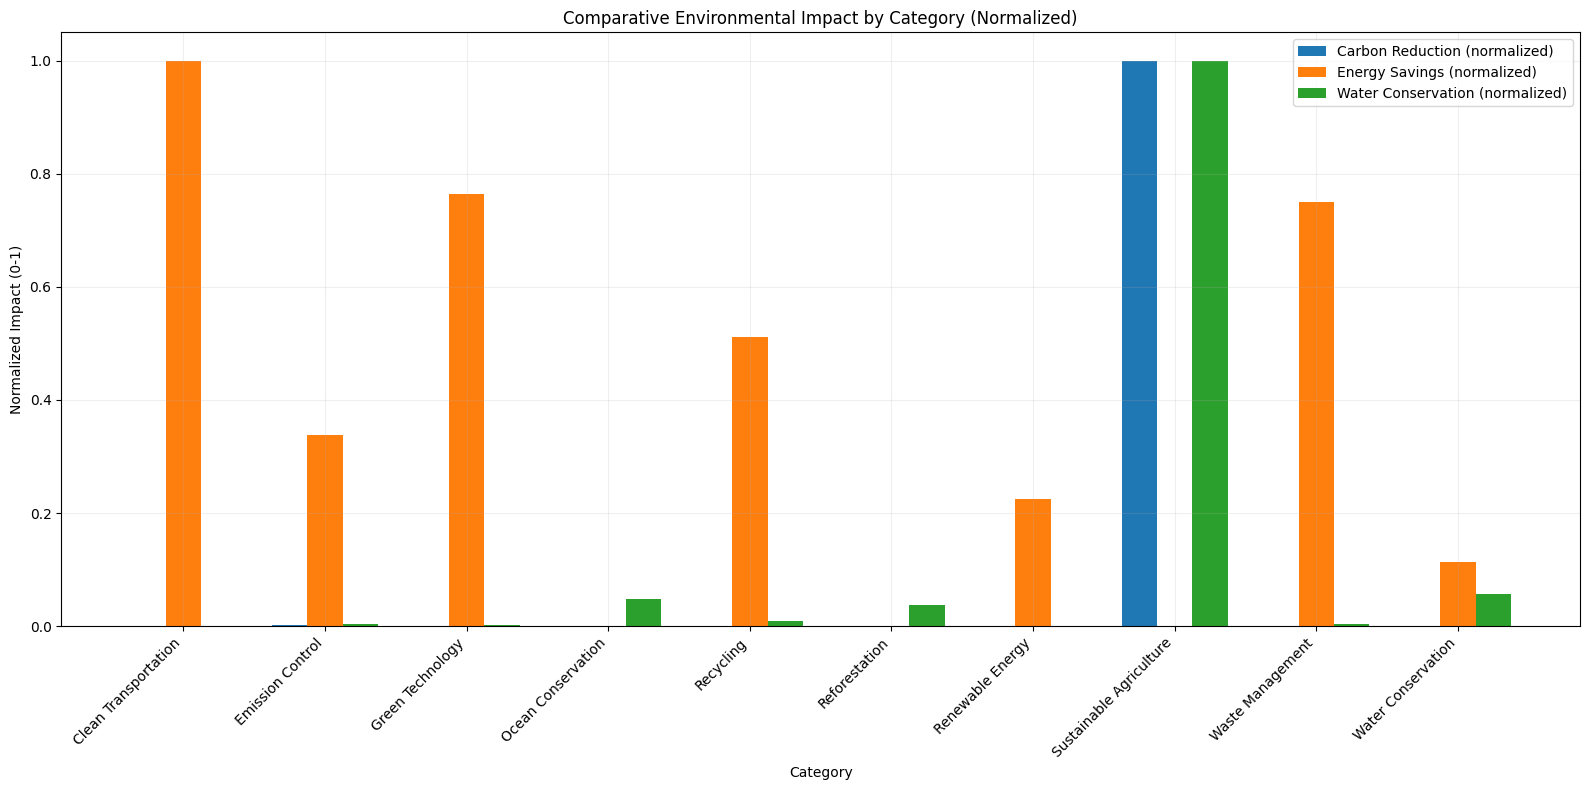

In [25]:
# Create a normalized comparative visualization of all three metrics
if 'category_impacts' in locals() and not category_impacts.empty:
    # Create a copy for normalization
    norm_df = category_impacts.copy()
    
    # Normalize each metric between 0 and 1 for comparison
    for metric in ['carbon', 'energy', 'water']:
        norm_df[f'{metric}_norm'] = (norm_df[metric] - norm_df[metric].min()) / \
                                  (norm_df[metric].max() - norm_df[metric].min())
    
    # Set up the figure
    plt.figure(figsize=(16, 8))
    
    # Plot normalized metrics
    x = np.arange(len(norm_df['category']))
    width = 0.25
    
    plt.bar(x - width, norm_df['carbon_norm'], width, label='Carbon Reduction (normalized)')
    plt.bar(x, norm_df['energy_norm'], width, label='Energy Savings (normalized)')
    plt.bar(x + width, norm_df['water_norm'], width, label='Water Conservation (normalized)')
    
    # Annotations and formatting
    plt.xlabel('Category')
    plt.ylabel('Normalized Impact (0-1)')
    plt.title('Comparative Environmental Impact by Category (Normalized)')
    plt.xticks(x, norm_df['category'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    # Show the original values alongside normalized ones
    comparison_df = norm_df[['category', 'count', 'carbon', 'carbon_norm', 
                           'energy', 'energy_norm', 'water', 'water_norm']]
    comparison_df = comparison_df.sort_values('category')
    comparison_df

In [27]:
# Export the data to CSV files for further analysis
if 'impact_df' in locals() and not impact_df.empty:
    try:
        # Save full impact data
        impact_df.to_csv('initiative_impacts.csv', index=False)
        print(f"Exported full initiative impact data to 'initiative_impacts.csv'")
        
        # Save category impact summary
        if 'category_impacts' in locals() and not category_impacts.empty:
            category_impacts.to_csv('category_impacts.csv', index=False)
            print(f"Exported category impact summary to 'category_impacts.csv'")
            
    except Exception as e:
        print(f"Error exporting data: {e}")
else:
    print("No data available to export.")

Exported full initiative impact data to 'initiative_impacts.csv'
Exported category impact summary to 'category_impacts.csv'
